# Fase 3: Extracción de características y modelado
---
Este cuaderno detalla la extracción de características para enriquecer nuestra base de datos con metadatos cuantitativos.

El objetivo es transformar el texto plano en variables numéricas y categóricas que permitan comparar la complejidad léxica y emocional de los artistas. El flujo de trabajo se divide en:
1. Métricas lingüísticas tradicionales: legibilidad, riqueza léxica, morfología.
2. Extracción de entidades nombradas (NER).
3. Clasificación emocional y temática mediante modelos de aprendizaje profundo.

### 3.1 Extracción de métricas léxicas y gramaticales
Se utilizó `textstat` para calcular el índice de legibilidad *Flesch-Kincaid* y el *Type-Token Ratio* para medir la diversidad del vocabulario. Paralelamente, `spaCy` extrae la proporción de categorías gramaticales (verbos, sustantivos, adjetivos y adverbios) y las entidades nombradas (personas, lugares y organizaciones).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import textstat
import spacy
import json
import re

from textblob import TextBlob
from transformers import pipeline
from tqdm.notebook import tqdm
from collections import Counter, defaultdict

import warnings
warnings.filterwarnings('ignore')

In [3]:
nlp = spacy.load("en_core_web_sm")

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/processed/taylor_swift_processed.csv')
print(f"Canciones cargadas: {len(df)}")

Canciones cargadas: 242


In [4]:
def calculate_lexical_metrics(row):
    text_full = row['lyrics_full']
    text_unique = row['lyrics_unique']

    words = text_full.split()
    word_count = len(words)
    line_count = len(text_full.split('\n'))

    unique_words = text_unique.lower().split()
    vocab_size = len(set(unique_words))

    ttr = vocab_size / len(unique_words) if len(unique_words) > 0 else 0

    try:
        readability = textstat.flesch_kincaid_grade(text_full)
    except:
        readability = 0

    doc = nlp(text_full)
    stopwords_count = sum([1 for token in doc if token.is_stop])
    stopword_ratio = stopwords_count / word_count if word_count > 0 else 0
    
    return pd.Series([word_count, line_count, vocab_size, ttr, readability, stopword_ratio])

df[['word_count', 'line_count', 'vocab_size', 'type_token_ratio', 'flesch_kincaid_grade', 'stopwords_ratio']] = df.apply(calculate_lexical_metrics, axis=1)

In [5]:
def grammar_analysis(text):
    doc = nlp(text)

    pos_counts = Counter([token.pos_ for token in doc])
    total_tokens = len(doc)

    noun_ratio = pos_counts['NOUN'] / total_tokens if total_tokens > 0 else 0
    verb_ratio = pos_counts['VERB'] / total_tokens if total_tokens > 0 else 0
    adj_ratio = pos_counts['ADJ'] / total_tokens if total_tokens > 0 else 0
    pron_ratio = pos_counts['PRON'] / total_tokens if total_tokens > 0 else 0

    ents = [ent.label_ for ent in doc.ents]
    ent_counts = Counter(ents)

    ent_person = ent_counts['PERSON']
    ent_place = ent_counts['GPE'] + ent_counts['LOC']
    ent_org = ent_counts['ORG']

    return pd.Series([noun_ratio, verb_ratio, adj_ratio, pron_ratio, ent_person, ent_place, ent_org])
df[['noun_ratio', 'verb_ratio', 'adj_ratio', 'pron_ratio', 'ent_person', 'ent_place', 'ent_org']] = df['lyrics_full'].apply(grammar_analysis)

In [6]:
df['sentiment_polarity'] = df['lyrics_full'].apply(lambda x: TextBlob(x).sentiment.polarity)

print("Cargando modelo...")

classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base", # anger, disgust, fear, joy, neutral, sadness, surprise
    top_k=None,
    truncation=True,
    batch_size=8
)

print("Analizando emociones de cada canción...")

emotions_list = [] # lista de listas de dicts
for lyrics in tqdm(df['lyrics_full']):
    predictions = classifier(lyrics)
    scores = {item['label']: item['score'] for item in predictions[0]} # formato: [{'label': emoción, 'score': puntuación}]
    emotions_list.append(scores)

emotions_df = pd.DataFrame(emotions_list)
df = pd.concat([df, emotions_df], axis=1)

df['dominant_emotion'] = emotions_df.idxmax(axis=1)

print("Emociones calculadas.")

Cargando modelo...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analizando emociones de cada canción...


  0%|          | 0/242 [00:00<?, ?it/s]

Emociones calculadas.


In [7]:
cols_order = [
    'title', 'album', 'year', 
    'word_count', 'line_count', 'vocab_size', 'type_token_ratio', 'flesch_kincaid_grade', 'stopwords_ratio',
    'noun_ratio', 'verb_ratio', 'adj_ratio', 'pron_ratio', 
    'ent_person', 'ent_place', 'ent_org',
    'sentiment_polarity', 'dominant_emotion',
    'joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust', 'neutral',
    'lyrics', 'lyrics_full', 'lyrics_unique', 'lyrics_norm'
]

cols_final = [c for c in cols_order if c in df.columns]
df_final = df[cols_final]

In [8]:
output_file = '../data/processed/taylor_swift_metrics.csv'
df_final.to_csv(output_file, index=False)

print(df_final[['title', 'noun_ratio', 'ent_person', 'sentiment_polarity', 'dominant_emotion']].head())

                    title  noun_ratio  ent_person  sentiment_polarity  \
0              Tim McGraw    0.147982         6.0            0.105707   
1         Picture to Burn    0.118598         1.0           -0.199537   
2  Teardrops on My Guitar    0.110193         2.0            0.260434   
3   A Place In This World    0.086420         0.0            0.216111   
4             Cold as You    0.075658         0.0            0.247917   

  dominant_emotion  
0          sadness  
1            anger  
2         surprise  
3          sadness  
4          sadness  


### 3.2 Clasificación temática y emocional
Inicialmente se evaluaron modelos de TextBlob y DistilRoBERTa, pero para lograr mayor granularidad, se evolucionó a las dos siguientes arquitecturas:
* **Zero-Shot Classificacition (BART-Large-MNLI):** Para asignar etiquetas temáticas no supervisadas sin necesidad de reentrenar el modelo.
* **GoEmotions (RoBERTa-base):** Un modelo de Google entrenado en Reddit que permite clasificar el texto en 28 emociones en lugar de las tradicionales 7 emociones básicas.

In [9]:
archivo_csv = '../data/processed/taylor_swift_metrics.csv'
df = pd.read_csv(archivo_csv)

In [10]:
clf_zeroshot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
labels = [
    "love", "heartbreak", "empowerment", "nostalgia", "friendship", 
    "self-reflection", "growth", "fun", "sadness", "anger", "revenge",
    "anxiety", "hope", "loneliness", "celebration", "loss", "forgiveness"
]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [11]:
clf_goemotions = pipeline("text-classification", model="samlowe/roberta-base-go_emotions", top_k=None)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: samlowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
themes_zs = []
scores_zs = []
emotions_go = []
score_go = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Analizando discografía"):
    lyrics = str(row['lyrics_full'])

    clean_lyrics = lyrics.replace('\n', ' ')
    cropped_lyrics = clean_lyrics[:800]

    try:
        res_zs = clf_zeroshot(cropped_lyrics, candidate_labels=labels)
        theme = res_zs['labels'][0]
        score_theme = res_zs['scores'][0]

        res_go = clf_goemotions(cropped_lyrics)[0]

        if isinstance(res_go, list):
            emotion = res_go[0]['label']
            score_emotion = res_go[0]['score']
        else:
            emotion = res_go['label']
            score_emotion = res_go['score']

    except Exception as e:
        print(f"Error procesando {row['title']}: {e}")
        theme, score_theme = "unknown", 0.0
        emotion, score_emotion = "unknown", 0.0
    
    themes_zs.append(theme)
    scores_zs.append(score_theme)
    emotions_go.append(emotion)
    score_go.append(score_emotion)

Analizando discografía:   0%|          | 0/242 [00:00<?, ?it/s]

In [13]:
df['theme_zeroshot'] = themes_zs
df['theme_score'] = scores_zs
df['emotion_goemotions'] = emotions_go
df['emotion_score'] = score_go

In [14]:
df.to_csv(archivo_csv, index=False)

In [15]:
print("\n--- Top temáticas (zero-shot) ---")
print(df['theme_zeroshot'].value_counts().head(10))

print("\n--- Top emociones (go_emotions) ---")
print(df['emotion_goemotions'].value_counts().head(10))


--- Top temáticas (zero-shot) ---
theme_zeroshot
loss               114
self-reflection     40
love                24
sadness             11
nostalgia           10
celebration          7
heartbreak           6
fun                  5
anger                5
revenge              4
Name: count, dtype: int64

--- Top emociones (go_emotions) ---
emotion_goemotions
neutral           96
love              38
sadness           27
disappointment    14
admiration        11
joy                9
desire             7
curiosity          7
annoyance          6
fear               6
Name: count, dtype: int64


### 3.3 Arco narrativo mediante ventanas deslizantes
Una canción no tiene una única emoción estática; cuenta una historia que evoluciona. Para capturar este "arco narrativo", se implementó un algoritmo de ventanas deslizantes. El modelo avanza bloque a bloque a través del texto, capturando cómo transitan los sentimientos.

In [16]:
def sliding_windows(text, window_size=50, step=25):
    words = text.split()
    windows = []
    for i in range(0, len(words), step):
        chunk = words[i:i + window_size]
        if len(chunk) > 0:
            windows.append(" ".join(chunk))
    return windows

In [17]:
dominant_emotions = []
emotions_sequence = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    lyrics = row['lyrics_full']
    chunks = sliding_windows(lyrics)

    scores = defaultdict(float)
    song_sequence = []
    
    for chunk in chunks:
        results = clf_goemotions(chunk)[0]

        song_sequence.append(results[0]['label'])
        
        for result in results:

            emotion = result['label']
            score = result['score']
            scores[emotion] += score

    emotions_sequence.append(song_sequence)
    
    num_chunks = len(chunks)
    for emotion in scores:
        scores[emotion] /= num_chunks
    
    winner = max(scores, key=scores.get)
    dominant_emotions.append(winner)

# df['emotion_goemotions'] = dominant_emotions

  0%|          | 0/242 [00:00<?, ?it/s]

In [18]:
song = "All Too Well (Taylor’s Version)"
test = df[df['title'] == song]['lyrics_full'].values[0]

chunks = sliding_windows(test)

emotions = ["admiration", "amusement", "anger", "annoyance", "approval", "caring",
            "confusion", "curiosity", "desire", "disappointment", "disapproval", 
            "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
            "joy", "love", "nervousness", "optimism", "pride", "realization", "relief",
            "remorse", "sadness", "surprise", "neutral"]

evolution = {emotion: [] for emotion in emotions}

for chunk in chunks:
    results = clf_goemotions(chunk)[0]
    dict_results = {res['label']: res['score'] for res in results}

    for emotion in emotions:
        evolution[emotion].append(dict_results.get(emotion, 0))

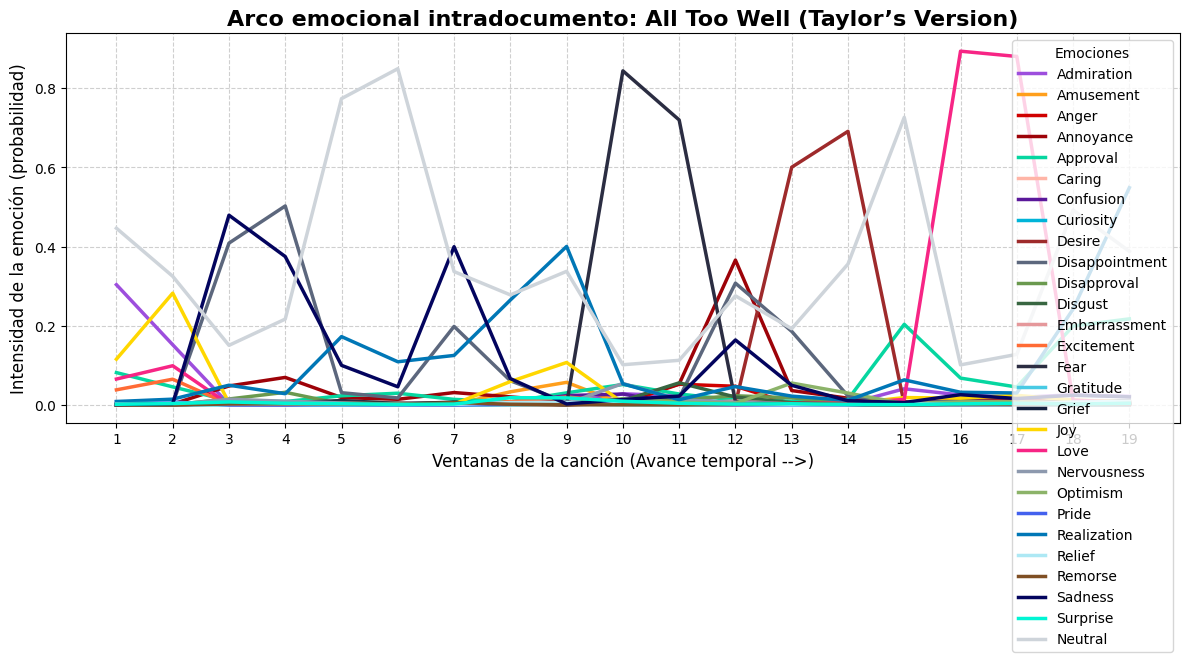

In [19]:
plt.figure(figsize=(12, 6))

colors = {"admiration": "#9d4edd", "amusement": "#ff9f1c", "anger": "#d00000", 
          "annoyance": "#9d0208", "approval": "#06d6a0", "caring": "#ffb5a7", 
          "confusion": "#5a189a", "curiosity": "#00b4d8", "desire": "#9e2a2b", 
          "disappointment": "#5c677d", "disapproval": "#6a994e", "disgust": "#386641", 
          "embarrassment": "#e5989b", "excitement": "#ff6b35", "fear": "#2b2d42", 
          "gratitude": "#48cae4", "grief": "#14213d", "joy": "#ffd700", "love": "#f72585", 
          "nervousness": "#8d99ae", "optimism": "#8cb369", "pride": "#4361ee", 
          "realization": "#0077b6", "relief": "#ade8f4", "remorse": "#7f4f24", 
          "sadness": "#03045e", "surprise": "#00f5d4", "neutral": "#ced4da"}

for emotion in emotions:
    sns.lineplot(x=range(1, len(chunks) + 1), y=evolution[emotion],
                 label=emotion.capitalize(), color=colors[emotion], linewidth=2.5)
    
plt.title(f"Arco emocional intradocumento: {song}", fontsize=16, fontweight='bold')
plt.xlabel("Ventanas de la canción (Avance temporal -->)", fontsize=12)
plt.ylabel("Intensidad de la emoción (probabilidad)", fontsize=12)
plt.xticks(range(1, len(chunks) + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Emociones", loc='upper right')

plt.tight_layout()
plt.show()

In [20]:
df['emotion_sliding'] = dominant_emotions
df['emotion_sliding_seq'] = [json.dumps(seq) for seq in emotions_sequence]

### 3.4 Segmentación estructural nativa y riqueza léxica evolutiva
Como mejora sobre la técnica empírica de ventanas deslizantes, se desarrolló una segmentación orgánica. Aprovechando las anotaciones estructurales de Genius, se dividió la canción en sus secciones arquitectónicas reales.
Sobre cada sección se recalcula la emoción predominante y el *Type-Token Ratio*, lo que permite visualizar cómo cambia la complejidad léxica de un artista cuando entra en un estribillo frente a un puente.

In [21]:
def get_genius_sections(text):
    sections = re.split(r'\[.*?\]', str(text))
    chunks = [sec.strip() for sec in sections if len(sec.strip()) > 5]
    return chunks

In [22]:
def calculate_ttr(text):
    words = str(text).lower().split()
    if len(words) == 0:
        return 0.0
    unique_vocab = set(words)
    return len(unique_vocab) / len(words)

In [23]:
# df_original = pd.read_csv('../data/processed/taylor_swift_processed.csv')
# df['lyrics'] = df_original['lyrics']

In [24]:
dominant_emotions = []
emotions_sequence = []
ttr_sequence = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    lyrics_raw = row['lyrics']
    chunks = get_genius_sections(lyrics_raw)

    scores = defaultdict(float)
    song_sequence = []
    song_ttr_sequence = []

    for chunk in chunks:
        results = clf_goemotions(chunk)[0]
        song_sequence.append(results[0]['label'])

        for result in results:
            emotion = result['label']
            score = result['score']
            scores[emotion] += score
        
        riqueza_lexica = calculate_ttr(chunk)
        song_ttr_sequence.append(round(riqueza_lexica, 3))
    
    emotions_sequence.append(song_sequence)
    ttr_sequence.append(song_ttr_sequence)

    num_chunks = len(chunks)

    if num_chunks > 0:
        for emotion in scores:
            scores[emotion] /= num_chunks
        winner = max(scores, key=scores.get)
    else:
        winner = "neutral"

    dominant_emotions.append(winner)

  0%|          | 0/242 [00:00<?, ?it/s]

In [25]:
df['emotion_genius'] = dominant_emotions
df['emotion_genius_seq'] = [json.dumps(seq) for seq in emotions_sequence]
df['ttr_genius_seq'] = [json.dumps(seq) for seq in ttr_sequence]

df.to_csv(archivo_csv, index=False)

print(f"\nProceso completado.\nEl archivo '{archivo_csv}' ha sido actualizado con éxito.")


Proceso completado.
El archivo '../data/processed/taylor_swift_metrics.csv' ha sido actualizado con éxito.
